# Toric-code-specific NES sampler

This notebook tests the flux-free initialization and runs the star/winding-loop Metropolis kernel. It is for the four toric-code ground states on a torus.


In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.home() / 'Desktop' / 'Master Thesis' / 'NES_Spins'
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
from nes_lattice.lattice import toric_code_move_masks, toric_code_plaquette_values
from nes_lattice.train import TrainConfig, train, save_history
from nes_lattice.plots import plot_history, plot_diagnostics, print_final


## 1. Static move check
Both star masks and winding-loop masks must preserve every plaquette value $B_p$.


In [2]:
shape = (4, 4)
star_masks, loop_masks = toric_code_move_masks(shape)
base = np.ones((1, 2 * shape[0] * shape[1]), dtype=np.int8)

for label, masks in [('stars', star_masks), ('loops', loop_masks)]:
    moved = np.concatenate([base * (1 - 2 * mask)[None, :] for mask in masks], axis=0)
    bp = toric_code_plaquette_values(moved, shape)
    assert np.all(bp == 1), f'{label} did not preserve B_p=+1'

print('star masks:', star_masks.shape)
print('loop masks:', loop_masks.shape)
print('All star and winding-loop moves preserve B_p=+1.')


star masks: (16, 32)
loop masks: (2, 32)
All star and winding-loop moves preserve B_p=+1.


## 2. First 4x4 ground-state baseline
Use `k=1` first. The sampler uses 90% star moves and 10% winding loops.


In [4]:
cfg = TrainConfig(
    shape=(4, 4),
    hamiltonian='toric_code',
    k=1,
    Je=1.0,
    Jm=1.0,

    model='vit',
    vit_patch_size=1,
    vit_d_model=64,
    vit_num_layers=4,
    vit_num_heads=4,
    vit_mlp_ratio=2,
    vit_use_positional_embeddings=False,

    steps=2000,
    lr=5e-4,
    grad_clip=1.0,
    n_chains=256,
    n_samples=16,
    sweep_steps=32,
    burn_in=320,

    toric_loop_prob=0.10,
    toric_single_flip_prob=0.0,
    toric_cover_sectors=True,

    print_every=250,
    eval_exact_if_sites_leq=12,
    eval_chains=256,
    eval_samples=64,
    reference='auto',
    seed=0,
)

params, history = train(cfg)

save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_4x4_k1_vit_toricmoves.json'
save_history(history, save_path, cfg)
print('saved to:', save_path)


{'step': 0, 'loss_sum': -29.85521697998047, 'train_energy_estimator': nan, 'energies': [-29.85521697998047], 'reference': [-32.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [2.1447830200195312], 'trace_error': 2.1447830200195312, 'condition_number_S': 1.0, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'eval': {'accept_rate': 0.6133880615234375, 'burn_accept_rate': 0.6185302734375, 'burn_loop_accept_rate': 0.6093469262123108, 'burn_loop_move_fraction': 0.10186767578125, 'burn_single_flip_accept_rate': 0.0, 'burn_single_flip_move_fraction': 0.0, 'burn_star_accept_rate': 0.61957186460495, 'burn_star_move_fraction': 0.89813232421875, 'loop_accept_rate': 0.6104022264480591, 'loop_move_fraction': 0.100004196166

## 3. Read the sampler diagnostics and plot


energies: [-32.00001907348633]
train_energy_estimator: -32.0
sampler_accept_rate: 0.9998626708984375
sampler_star_accept_rate: 0.999856173992157
sampler_loop_accept_rate: 0.999922513961792
sampler_star_move_fraction: 0.901519775390625
sampler_loop_move_fraction: 0.098480224609375
invalid_bundle_fraction: 0.0
File:               /home/a/Anas.Roumeih/Desktop/Master Thesis/NES_Spins/results/sampled_nes_toric_4x4_k1_vit_toricmoves.json
Config:             {'shape': [4, 4], 'hamiltonian': 'toric_code', 'k': 1, 'J': 1.0, 'g': 1.0, 'Je': 1.0, 'Jm': 1.0, 'pbc': True, 'magnetization': None, 'model': 'vit', 'hidden': [64, 64], 'rbm_hidden': 32, 'channels': [16, 16], 'kernel_size': 3, 'vit_patch_size': 1, 'vit_d_model': 64, 'vit_num_layers': 4, 'vit_num_heads': 4, 'vit_mlp_ratio': 2, 'vit_use_positional_embeddings': False, 'vit_log_amplitude_clip': 20.0, 'init_scale': 0.05, 'dtype': 'float32', 'steps': 2000, 'lr': 0.0005, 'n_chains': 256, 'n_samples': 16, 'sweep_steps': 32, 'burn_in': 320, 'grad_

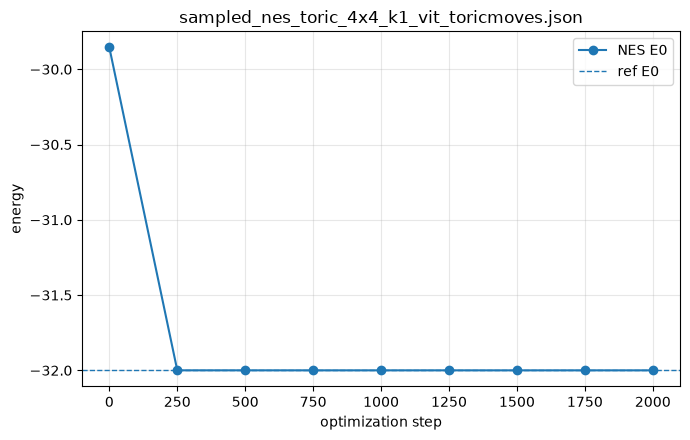

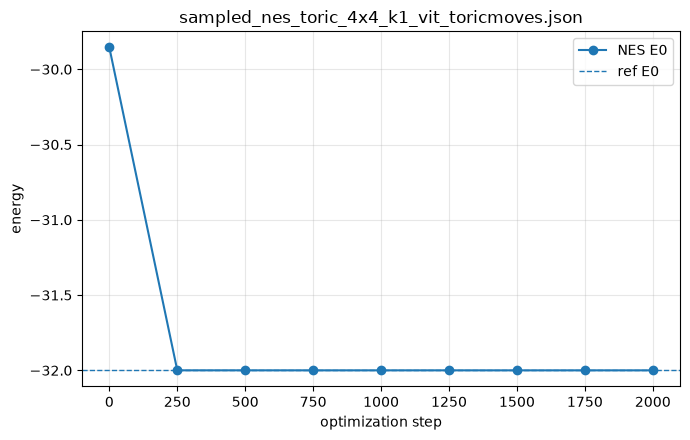

In [ ]:
final = history[-1]
for key in [
    'energies',
    'train_energy_estimator',
    'sampler_accept_rate',
    'sampler_star_accept_rate',
    'sampler_loop_accept_rate',
    'sampler_star_move_fraction',
    'sampler_loop_move_fraction',
    'invalid_bundle_fraction',
]:
    print(f'{key}:', final.get(key))

print_final(save_path)
fig, ax = plot_history(save_path)


## 4. Fourfold ground space
Run this only after the `k=1` baseline is behaving reasonably.


In [9]:
cfg4 = TrainConfig(
    shape=(4, 4),
    hamiltonian='toric_code',
    k=4,
    Je=1.0,
    Jm=1.0,

    model='vit',
    vit_patch_size=1,
    vit_d_model=64,
    vit_num_layers=4,
    vit_num_heads=4,
    vit_mlp_ratio=2,
    vit_use_positional_embeddings=False,

    steps=5000,
    lr=2e-4,
    grad_clip=1.0,
    n_chains=36,
    n_samples=16,
    sweep_steps=32,
    burn_in=320,

    toric_loop_prob=0.10,
    toric_single_flip_prob=0.0,
    toric_cover_sectors=True,

    print_every=500,
    eval_exact_if_sites_leq=12,
    eval_chains=256,
    eval_samples=64,
    reference='auto',
    seed=1,
)

params4, history4 = train(cfg4)
save_path4 = PROJECT_ROOT / 'results' / 'sampled_nes_toric_4x4_k4_vit_toricmoves.json'
save_history(history4, save_path4, cfg4)
print('saved to:', save_path4)


{'step': 0, 'loss_sum': -107.25477450136303, 'train_energy_estimator': nan, 'energies': [-31.597734949216875, -26.989729198689155, -24.785999006795663, -23.881311346661334], 'reference': [-32.0, -32.0, -32.0, -32.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [0.40226505078312513, 5.0102708013108455, 7.214000993204337, 8.118688653338666], 'trace_error': 20.74522549863697, 'condition_number_S': 36.83647294898163, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'eval': {'accept_rate': 0.7792129516601562, 'burn_accept_rate': 0.779492199420929, 'burn_loop_accept_rate': 0.7702503204345703, 'burn_loop_move_fraction': 0.09946288913488388, 'burn_single_flip_accept_rate': 0.0, 'burn_single_flip_move_fraction': 0.0, '

File:               /home/a/Anas.Roumeih/Desktop/Master Thesis/NES_Spins/results/sampled_nes_toric_4x4_k4_vit_toricmoves.json
Config:             {'shape': [4, 4], 'hamiltonian': 'toric_code', 'k': 4, 'J': 1.0, 'g': 1.0, 'Je': 1.0, 'Jm': 1.0, 'pbc': True, 'magnetization': None, 'model': 'vit', 'hidden': [64, 64], 'rbm_hidden': 32, 'channels': [16, 16], 'kernel_size': 3, 'vit_patch_size': 1, 'vit_d_model': 64, 'vit_num_layers': 4, 'vit_num_heads': 4, 'vit_mlp_ratio': 2, 'vit_use_positional_embeddings': False, 'vit_log_amplitude_clip': 20.0, 'init_scale': 0.05, 'dtype': 'float32', 'steps': 5000, 'lr': 0.0002, 'n_chains': 36, 'n_samples': 16, 'sweep_steps': 32, 'burn_in': 320, 'grad_clip': 1.0, 'toric_loop_prob': 0.1, 'toric_single_flip_prob': 0.0, 'toric_cover_sectors': True, 'print_every': 500, 'eval_exact_if_sites_leq': 12, 'eval_samples': 64, 'eval_chains': 256, 'reference': 'auto', 'own_ed_max_sites': 14, 'netket_max_states': 2000000, 'jitter': 1e-06, 'seed': 1}
Final NES energies: [

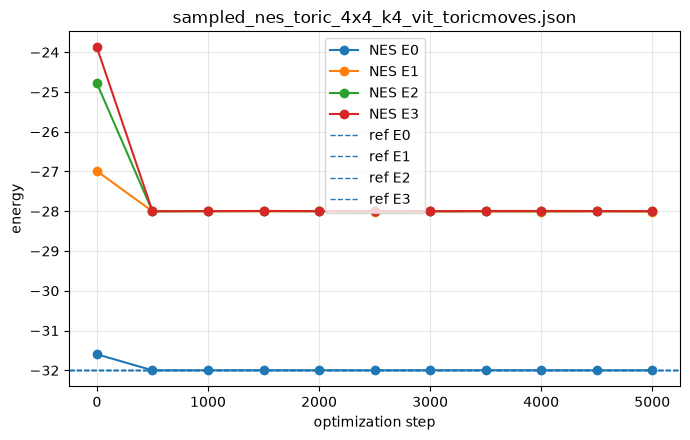

In [11]:
print_final(save_path4)
fig, ax = plot_history(save_path4)

{'step': 0, 'loss_sum': -1.866352522059837, 'train_energy_estimator': nan, 'energies': [-1.866352522059837], 'reference': [-8.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [6.133647477940163], 'trace_error': 6.133647477940163, 'condition_number_S': 1.0, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'eval': {'S_min_eig': 752.0577392578125, 'S_max_eig': 752.0577392578125, 'S_rank': 1, 'S_floor': 1e-06, 'S_num_clipped': 0, 'S_eigenvalues': [752.0577392578125], 'method': 'exact_span', 'accept_rate': None}}
{'step': 500, 'loss_sum': -5.22982469093062, 'train_energy_estimator': -5.390406608581543, 'energies': [-5.22982469093062], 'reference': [-8.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy

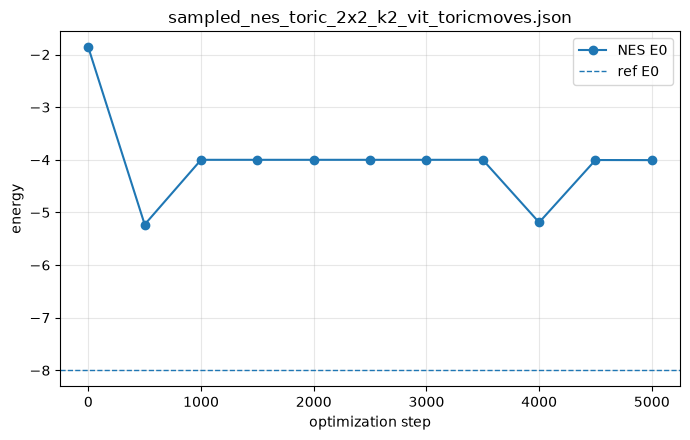

In [17]:
cfg2 = TrainConfig(
    shape=(2, 2),
    hamiltonian='toric_code',
    k=1,
    Je=1.0,
    Jm=1.0,

    model='vit',
    vit_patch_size=1,
    vit_d_model=64,
    vit_num_layers=4,
    vit_num_heads=4,
    vit_mlp_ratio=2,
    vit_use_positional_embeddings=False,

    steps=5000,
    lr=5e-4,
    n_chains=128,
    n_samples=18,
    sweep_steps=32,
    burn_in=32,

    toric_loop_prob=0.05,
    toric_single_flip_prob=0.15,
    toric_cover_sectors=True,

    print_every=500,
    eval_exact_if_sites_leq=12,
    eval_chains=256,
    eval_samples=64,
    reference='auto',
    seed=1,
)

params2, history2 = train(cfg2)
save_path2 = PROJECT_ROOT / 'results' / 'sampled_nes_toric_2x2_k2_vit_toricmoves.json'
save_history(history2, save_path2, cfg2)
print_final(save_path2)
fig, ax = plot_history(save_path2)

In [4]:
for rec in history2:
    print(
        rec["step"],
        "train:", rec.get("train_energy"),
        "energies:", rec["energies"],
        "condS:", rec.get("condition_number_S"),
        "rank:", rec.get("S_rank"),
        "accept:", rec.get("sampler_accept_rate"),
    )

0 train: None energies: [-1.8663444818436663] condS: 1.0 rank: None accept: nan
500 train: None energies: [-4.000084904827349] condS: 1.0 rank: None accept: 0.0
1000 train: None energies: [-4.0000656634522365] condS: 1.0 rank: None accept: 0.0
1500 train: None energies: [-4.0000657273956275] condS: 1.0 rank: None accept: 0.0
2000 train: None energies: [-4.000071844839097] condS: 1.0 rank: None accept: 0.0


# Diagnostics

In [20]:
import itertools
import numpy as np

from nes_lattice.lattice import toric_code_terms, toric_code_num_edges

shape = (2, 2)
stars, plaquettes = toric_code_terms(shape, pbc=True)

stars = np.asarray(stars, dtype=int)
plaquettes = np.asarray(plaquettes, dtype=int)
N = toric_code_num_edges(shape)

all_up = np.ones(N, dtype=np.int8)

# One topological-sector ground-state support:
# all configurations reachable from all-up by products of star flips.
orbit = set()

for bits in itertools.product([0, 1], repeat=len(stars)):
    s = all_up.copy()
    for use_star, star in zip(bits, stars):
        if use_star:
            s[star] *= -1
    orbit.add(tuple(s.tolist()))

print("N edges:", N)
print("number of distinct star-orbit configurations:", len(orbit))
print("stars:\n", stars)
print("plaquettes:\n", plaquettes)


def psi(s):
    return 1.0 if tuple(np.asarray(s).tolist()) in orbit else 0.0


def local_energy(s):
    s = np.asarray(s, dtype=np.int8)

    # -sum_p B_p in the z basis
    diagonal = -np.sum(np.prod(s[plaquettes], axis=1))

    # -sum_s A_s: each star flip should remain in the orbit
    off_diagonal = 0.0
    for star in stars:
        flipped = s.copy()
        flipped[star] *= -1
        off_diagonal -= psi(flipped) / psi(s)

    return diagonal + off_diagonal


energies = np.array([local_energy(s) for s in orbit])

print("unique local energies in exact star-orbit state:", np.unique(energies))
print("expected:", -8.0)

N edges: 8
number of distinct star-orbit configurations: 8
stars:
 [[0 4 1 3]
 [2 6 3 1]
 [4 0 5 7]
 [6 2 7 5]]
plaquettes:
 [[0 5 2 1]
 [2 7 0 3]
 [4 1 6 5]
 [6 3 4 7]]
unique local energies in exact star-orbit state: [-8.]
expected: -8.0


In [2]:
import inspect
import nes_lattice.nes as nes

print(inspect.getsource(nes._local_energy_bundle_valid))

def _local_energy_bundle_valid(
    apply_fun,
    params,
    bundle: jnp.ndarray,
    hspec: HamiltonianSpec,
    bonds: jnp.ndarray,
):
    """NES local energy for a bundle with finite, nonzero determinant."""
    A = amplitude_matrix(apply_fun, params, bundle)
    dtype = A.dtype
    k, N = bundle.shape

    Ainv = jnp.linalg.solve(A, jnp.eye(k, dtype=dtype))

    # Keep the full local-energy calculation in the ansatz dtype.
    e = jnp.asarray(jnp.sum(diag_energy(bundle, hspec, bonds)), dtype=dtype)

    if hspec.name == "tfim":
        g = jnp.asarray(hspec.g, dtype=dtype)

        for rep in range(k):
            for site in range(N):
                new_config = bundle[rep].at[site].multiply(-1)
                v = apply_fun(params, new_config[None, :])[0].astype(dtype)
                ratio = (Ainv @ v)[rep]
                e = e - g * ratio

    elif hspec.name == "heisenberg":
        J = jnp.asarray(hspec.J, dtype=dtype)

        for rep in range(k):
            s = bundle[

In [15]:
cfg = TrainConfig(
    shape=(2, 2),
    hamiltonian="toric_code",
    k=1,
    Je=1.0,
    Jm=1.0,

    model="vit",
    vit_patch_size=1,
    vit_d_model=32,
    vit_num_layers=2,
    vit_num_heads=4,
    vit_mlp_ratio=2,
    vit_use_positional_embeddings=True,

    steps=5000,
    lr=2e-4,
    grad_clip=1.0,

    n_chains=128,
    n_samples=12,
    sweep_steps=16,
    burn_in=16,

    # 85% star moves, 10% sector loops, 5% flux-changing moves.
    toric_loop_prob=0.10,
    toric_single_flip_prob=0.05,
    toric_cover_sectors=False,

    print_every=250,
    eval_exact_if_sites_leq=12,
    reference="auto",
    seed=2,
)

params, history = train(cfg)

save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_4x4_k1_vit_toricmoves.json'
save_history(history, save_path, cfg)
print('saved to:', save_path)

{'step': 0, 'loss_sum': -1.2842737083080398, 'train_energy_estimator': nan, 'energies': [-1.2842737083080398], 'reference': [-8.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [6.7157262916919604], 'trace_error': 6.7157262916919604, 'condition_number_S': 1.0, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'eval': {'S_min_eig': 10768.677734375, 'S_max_eig': 10768.677734375, 'S_rank': 1, 'S_floor': 1.0768677734375e-06, 'S_num_clipped': 0, 'S_eigenvalues': [10768.677734375], 'method': 'exact_span', 'accept_rate': None}}
{'step': 250, 'loss_sum': -6.298440022325517, 'train_energy_estimator': -6.157914638519287, 'energies': [-6.298440022325517], 'reference': [-8.0], 'reference_source': 'toric_code_exact_4fold_gro

In [17]:
final = history[-1]
print("energy:", final["energies"])
print("overall acceptance:", final["sampler_accept_rate"])
print("star acceptance:", final["sampler_star_accept_rate"])
print("single acceptance:", final["sampler_single_flip_accept_rate"])

energy: [-6.828262924896331]
overall acceptance: 0.4242350459098816
star acceptance: 0.4964761734008789
single acceptance: 0.0


In [10]:
cfg_diag = TrainConfig(
    shape=(2, 2),
    hamiltonian="toric_code",
    k=1,
    Je=1.0,
    Jm=1.0,

    model="vit",
    vit_patch_size=1,
    vit_d_model=32,
    vit_num_layers=2,
    vit_num_heads=4,
    vit_mlp_ratio=2,
    vit_use_positional_embeddings=True,

    steps=5000,
    lr=2e-4,
    grad_clip=1.0,

    n_chains=128,
    n_samples=12,
    sweep_steps=16,
    burn_in=16,

    toric_loop_prob=0.10,
    toric_single_flip_prob=0.05,
    toric_cover_sectors=False,

    
    print_every=500,
    eval_exact_if_sites_leq=12,
    eval_chains=256,
    eval_samples=64,

    reference="auto",
    seed=2,
)

params_diag, history_diag = train(cfg_diag)

save_path_diag = (
    PROJECT_ROOT
    / "results"
    / "debug_toric_2x2_k1_vit_gradientcheck.json"
)

save_history(history_diag, save_path_diag, cfg_diag)

print("Saved:", save_path_diag)
print("Final logged record:")
print(history_diag[-1])

{'step': 0, 'loss_sum': -1.2842743431062638, 'train_energy_estimator': nan, 'energies': [-1.2842743431062638], 'reference': [-8.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [6.715725656893737], 'trace_error': 6.715725656893737, 'condition_number_S': 1.0, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'eval': {'S_min_eig': 10768.677734375, 'S_max_eig': 10768.677734375, 'S_rank': 1, 'S_floor': 1.0768677734375e-06, 'S_num_clipped': 0, 'S_eigenvalues': [10768.677734375], 'method': 'exact_span', 'accept_rate': None}}
{'step': 500, 'loss_sum': -6.443134081944586, 'train_energy_estimator': -6.4492011070251465, 'energies': [-6.443134081944586], 'reference': [-8.0], 'reference_source': 'toric_code_exact_4fold_grou

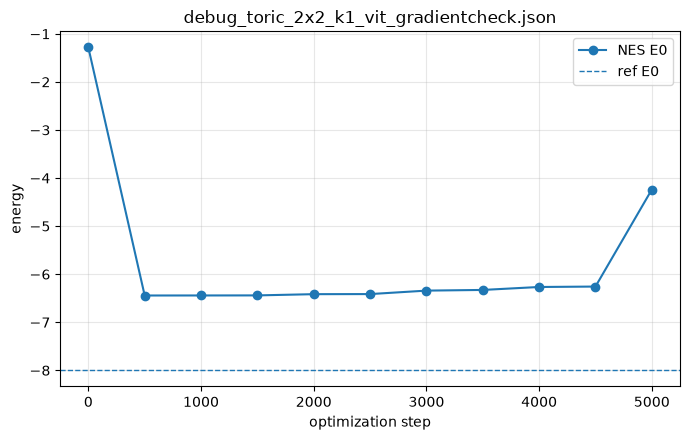

In [8]:
fig, ax = plot_history(save_path_diag)

In [6]:
import jax
import jax.numpy as jnp

from nes_lattice.hamiltonians import (
    make_hamiltonian_spec,
    apply_hamiltonian_to_state_values,
)
from nes_lattice.models import ModelSpec, apply_model

# Keep these names fixed: they identify the exact run under inspection.
params_for_diag = params_diag
cfg_for_diag = cfg_diag
history_for_diag = history_diag

# Recreate exactly the same Hamiltonian/model interface as train().
hspec = make_hamiltonian_spec(
    name=cfg_for_diag.hamiltonian,
    shape=cfg_for_diag.shape,
    J=cfg_for_diag.J,
    g=cfg_for_diag.g,
    pbc=cfg_for_diag.pbc,
    magnetization=cfg_for_diag.magnetization,
    Je=cfg_for_diag.Je,
    Jm=cfg_for_diag.Jm,
)

bonds = jnp.asarray(hspec.bonds_np)

mspec = ModelSpec(
    model=cfg_for_diag.model,
    shape=cfg_for_diag.shape,
    k=cfg_for_diag.k,
    hidden=cfg_for_diag.hidden,
    rbm_hidden=cfg_for_diag.rbm_hidden,
    channels=cfg_for_diag.channels,
    kernel_size=cfg_for_diag.kernel_size,
    vit_patch_size=cfg_for_diag.vit_patch_size,
    vit_d_model=cfg_for_diag.vit_d_model,
    vit_num_layers=cfg_for_diag.vit_num_layers,
    vit_mlp_ratio=cfg_for_diag.vit_mlp_ratio,
    vit_use_positional_embeddings=cfg_for_diag.vit_use_positional_embeddings,
    vit_log_amplitude_clip=cfg_for_diag.vit_log_amplitude_clip,
    scale=cfg_for_diag.init_scale,
    n_sites=hspec.N,
    input_channels=hspec.model_input_channels,
    dtype=cfg_for_diag.dtype,
)

def apply_fun(p, spins):
    return apply_model(p, spins, mspec)

# Full spin basis, 2^N configurations. For 2x2 toric code, N=8.
N = int(hspec.N)
integers = jnp.arange(1 << N, dtype=jnp.uint32)
bit_positions = jnp.arange(N, dtype=jnp.uint32)

basis = (
    2 * ((integers[:, None] >> bit_positions) & 1).astype(jnp.int8) - 1
).astype(jnp.int8)

psi = apply_fun(params_for_diag, basis)[:, 0]
Hpsi = apply_hamiltonian_to_state_values(
    apply_fun,
    params_for_diag,
    basis,
    hspec,
    bonds,
)[:, 0]

norm = jnp.sum(psi**2)
E_exact = jnp.sum(psi * Hpsi) / norm

stars = bonds[0]
plaquettes = bonds[1]

# <B_p>
Bp_values = jnp.prod(basis[:, plaquettes], axis=-1)
Bp_expectation = jnp.sum((psi[:, None] ** 2) * Bp_values, axis=0) / norm

# <A_s>
As_expectations = []
for star in stars:
    flipped_basis = basis.at[:, star].multiply(-1)
    psi_flipped = apply_fun(params_for_diag, flipped_basis)[:, 0]
    As_expectations.append(jnp.sum(psi * psi_flipped) / norm)

As_expectation = jnp.asarray(As_expectations)

print("Logged train estimator:", history_for_diag[-1]["train_energy_estimator"])
print("Exact full energy:     ", float(E_exact))
print()
print("<B_p>:", Bp_expectation)
print("<A_s>:", As_expectation)
print()
print("sum <B_p>:", float(jnp.sum(Bp_expectation)))
print("sum <A_s>:", float(jnp.sum(As_expectation)))
print("Reconstructed energy:", float(-jnp.sum(Bp_expectation) - jnp.sum(As_expectation)))

Logged train estimator: -6.449565410614014
Exact full energy:      -4.239311218261719

<B_p>: [0.5908441  0.59084255 0.5908415  0.59084517]
<A_s>: [0.31074244 0.62729406 0.62736624 0.31053534]

sum <B_p>: 2.363373279571533
sum <A_s>: 1.875938057899475
Reconstructed energy: -4.239311218261719


In [7]:
from jax.tree_util import tree_leaves, tree_map

def exact_energy(p):
    psi_p = apply_fun(p, basis)[:, 0]
    Hpsi_p = apply_hamiltonian_to_state_values(
        apply_fun,
        p,
        basis,
        hspec,
        bonds,
    )[:, 0]

    return jnp.sum(psi_p * Hpsi_p) / jnp.sum(psi_p**2)


def exact_vmc_surrogate(p):
    """Full-Hilbert-space analogue of the project's k=1 VMC gradient."""
    psi_p = apply_fun(p, basis)[:, 0]

    Hpsi_p = apply_hamiltonian_to_state_values(
        apply_fun,
        p,
        basis,
        hspec,
        bonds,
    )[:, 0]

    probability = jax.lax.stop_gradient(
        psi_p**2 / jnp.sum(psi_p**2)
    )

    e_local = Hpsi_p / psi_p
    e_mean = jax.lax.stop_gradient(
        jnp.sum(probability * e_local)
    )

    return jnp.sum(
        probability
        * 2.0
        * jax.lax.stop_gradient(e_local - e_mean)
        * jnp.log(psi_p)
    )


def tree_dot(tree_a, tree_b):
    return sum(
        jnp.vdot(a, b)
        for a, b in zip(tree_leaves(tree_a), tree_leaves(tree_b))
    )


grad_exact = jax.grad(exact_energy)(params_for_diag)
grad_vmc = jax.grad(exact_vmc_surrogate)(params_for_diag)

grad_difference = tree_map(
    lambda a, b: a - b,
    grad_exact,
    grad_vmc,
)

norm_exact = jnp.sqrt(tree_dot(grad_exact, grad_exact))
norm_vmc = jnp.sqrt(tree_dot(grad_vmc, grad_vmc))
norm_difference = jnp.sqrt(tree_dot(grad_difference, grad_difference))

cosine_similarity = tree_dot(grad_exact, grad_vmc) / (
    norm_exact * norm_vmc + 1e-30
)

relative_difference = norm_difference / (norm_exact + 1e-30)

print("Exact energy:               ", float(exact_energy(params_for_diag)))
print("Exact-gradient norm:        ", float(norm_exact))
print("VMC-surrogate gradient norm:", float(norm_vmc))
print("Gradient cosine similarity: ", float(cosine_similarity))
print("Relative gradient difference:", float(relative_difference))

Exact energy:                -4.239311218261719
Exact-gradient norm:         188.87844848632812
VMC-surrogate gradient norm: 188.83815002441406
Gradient cosine similarity:  1.0
Relative gradient difference: 0.0002673152484931052


In [9]:
from nes_lattice.adam import init_adam, adam_step, clip_grads
import jax
import jax.numpy as jnp

# Uses exact_energy(p) that you already defined in diagnostic 3.
params_exact = params_diag
opt_exact = init_adam(params_exact)

@jax.jit
def exact_step(params, opt):
    energy, grads = jax.value_and_grad(exact_energy)(params)
    grads, grad_norm = clip_grads(grads, 1.0)
    params, opt = adam_step(params, grads, opt, lr=1e-3)
    return params, opt, energy, grad_norm

for step in range(2001):
    if step % 100 == 0:
        E = exact_energy(params_exact)
        print(step, float(E))

    if step < 2000:
        params_exact, opt_exact, energy, grad_norm = exact_step(
            params_exact, opt_exact
        )

0 -4.239311218261719
100 -6.449432373046875
200 -6.449483871459961
300 -6.44948148727417
400 -6.449367523193359
500 -6.449492454528809
600 -6.449410438537598
700 -6.44949197769165
800 -6.643658638000488
900 -6.82832145690918
1000 -6.828427314758301
1100 -6.828428268432617
1200 -6.828426837921143
1300 -6.828427791595459
1400 -6.828428268432617
1500 -6.828428268432617
1600 -6.828426837921143
1700 -6.828427314758301
1800 -6.828427791595459
1900 -6.828427791595459
2000 -6.828426837921143


# Diagnostics 2

In [11]:
from nes_lattice.train import TrainConfig, train, save_history

cfg_diag = TrainConfig(
    shape=(2, 2),
    hamiltonian="toric_code",
    k=1,
    Je=1.0,
    Jm=1.0,

    model="vit",
    vit_patch_size=1,
    vit_d_model=32,
    vit_num_layers=2,
    vit_num_heads=4,
    vit_mlp_ratio=2,
    vit_use_positional_embeddings=True,

    steps=4000,
    lr=2e-4,
    grad_clip=1.0,

    n_chains=128,
    n_samples=12,
    sweep_steps=16,
    burn_in=16,

    toric_loop_prob=0.10,
    toric_single_flip_prob=0.05,
    toric_cover_sectors=False,

    # One exact evaluation at the end only.
    print_every=4000,
    eval_exact_if_sites_leq=12,
    eval_chains=256,
    eval_samples=64,

    reference="auto",
    seed=2,
)

params_diag, history_diag = train(cfg_diag)

save_path_diag = (
    PROJECT_ROOT
    / "results"
    / "debug_toric_2x2_k1_vit_gradientcheck.json"
)

save_history(history_diag, save_path_diag, cfg_diag)

print("Saved:", save_path_diag)
print("Final logged energy:", history_diag[-1]["energies"])
print("Final train estimator:", history_diag[-1]["train_energy_estimator"])

{'step': 0, 'loss_sum': -1.2842743431062638, 'train_energy_estimator': nan, 'energies': [-1.2842743431062638], 'reference': [-8.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [6.715725656893737], 'trace_error': 6.715725656893737, 'condition_number_S': 1.0, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'eval': {'S_min_eig': 10768.677734375, 'S_max_eig': 10768.677734375, 'S_rank': 1, 'S_floor': 1.0768677734375e-06, 'S_num_clipped': 0, 'S_eigenvalues': [10768.677734375], 'method': 'exact_span', 'accept_rate': None}}
{'step': 4000, 'loss_sum': -5.74966577628094, 'train_energy_estimator': -6.000007152557373, 'energies': [-5.74966577628094], 'reference': [-8.0], 'reference_source': 'toric_code_exact_4fold_ground

In [12]:
import jax
import jax.numpy as jnp

from nes_lattice.hamiltonians import (
    make_hamiltonian_spec,
    apply_hamiltonian_to_state_values,
)
from nes_lattice.lattice import make_basis
from nes_lattice.models import ModelSpec
from nes_lattice.train import make_apply_fun

# Use only these variables below.
params_for_diag = params_diag
cfg_for_diag = cfg_diag
history_for_diag = history_diag

hspec = make_hamiltonian_spec(
    name=cfg_for_diag.hamiltonian,
    shape=cfg_for_diag.shape,
    J=cfg_for_diag.J,
    g=cfg_for_diag.g,
    pbc=cfg_for_diag.pbc,
    magnetization=cfg_for_diag.magnetization,
    Je=cfg_for_diag.Je,
    Jm=cfg_for_diag.Jm,
)

bonds = jnp.asarray(hspec.bonds_np)

mspec = ModelSpec(
    model=cfg_for_diag.model,
    shape=cfg_for_diag.shape,
    k=cfg_for_diag.k,
    hidden=cfg_for_diag.hidden,
    rbm_hidden=cfg_for_diag.rbm_hidden,
    channels=cfg_for_diag.channels,
    kernel_size=cfg_for_diag.kernel_size,
    vit_patch_size=cfg_for_diag.vit_patch_size,
    vit_d_model=cfg_for_diag.vit_d_model,
    vit_num_layers=cfg_for_diag.vit_num_layers,
    vit_num_heads=cfg_for_diag.vit_num_heads,
    vit_mlp_ratio=cfg_for_diag.vit_mlp_ratio,
    vit_use_positional_embeddings=cfg_for_diag.vit_use_positional_embeddings,
    vit_log_amplitude_clip=cfg_for_diag.vit_log_amplitude_clip,
    scale=cfg_for_diag.init_scale,
    n_sites=hspec.N,
    input_channels=hspec.model_input_channels,
    dtype=cfg_for_diag.dtype,
)

apply_fun = make_apply_fun(mspec)

# Full 2^8 basis for the 2x2 toric code.
basis = jnp.asarray(make_basis((hspec.N,), None))

def report_toric_state(params, label):
    psi = apply_fun(params, basis)[:, 0]

    Hpsi = apply_hamiltonian_to_state_values(
        apply_fun,
        params,
        basis,
        hspec,
        bonds,
    )[:, 0]

    norm = jnp.sum(psi**2)
    energy = jnp.sum(psi * Hpsi) / norm

    stars = bonds[0]
    plaquettes = bonds[1]

    bp_values = jnp.prod(basis[:, plaquettes], axis=-1)
    bp_expectation = jnp.sum(
        (psi[:, None] ** 2) * bp_values,
        axis=0,
    ) / norm

    as_values = []
    for star in stars:
        flipped = basis.at[:, star].multiply(-1)
        psi_flipped = apply_fun(params, flipped)[:, 0]
        as_values.append(jnp.sum(psi * psi_flipped) / norm)

    as_expectation = jnp.asarray(as_values)

    print(f"\n--- {label} ---")
    print("Exact energy:", float(energy))
    print("<B_p>:", bp_expectation)
    print("<A_s>:", as_expectation)
    print("sum <B_p>:", float(jnp.sum(bp_expectation)))
    print("sum <A_s>:", float(jnp.sum(as_expectation)))
    print(
        "Reconstructed E:",
        float(-jnp.sum(bp_expectation) - jnp.sum(as_expectation)),
    )

    return energy

E_before = report_toric_state(
    params_for_diag,
    "State returned by train()",
)

print("\nLogged train estimator:",
      history_for_diag[-1]["train_energy_estimator"])


--- State returned by train() ---
Exact energy: -5.7496657371521
<B_p>: [0.9499252 0.9499252 0.9499252 0.9499252]
<A_s>: [1.7804783e-05 9.7496557e-01 9.7497028e-01 1.1156648e-05]
sum <B_p>: 3.7997007369995117
sum <A_s>: 1.9499647617340088
Reconstructed E: -5.749665260314941

Logged train estimator: -6.000007152557373


In [13]:
from jax.tree_util import tree_leaves, tree_map

def exact_energy(params):
    psi = apply_fun(params, basis)[:, 0]

    Hpsi = apply_hamiltonian_to_state_values(
        apply_fun,
        params,
        basis,
        hspec,
        bonds,
    )[:, 0]

    return jnp.sum(psi * Hpsi) / jnp.sum(psi**2)


def exact_vmc_surrogate(params):
    """Exact full-basis counterpart of your k=1 sampled VMC loss."""
    psi = apply_fun(params, basis)[:, 0]

    Hpsi = apply_hamiltonian_to_state_values(
        apply_fun,
        params,
        basis,
        hspec,
        bonds,
    )[:, 0]

    e_local = Hpsi / psi

    probability = jax.lax.stop_gradient(
        psi**2 / jnp.sum(psi**2)
    )

    e_mean = jax.lax.stop_gradient(
        jnp.sum(probability * e_local)
    )

    return jnp.sum(
        probability
        * 2.0
        * jax.lax.stop_gradient(e_local - e_mean)
        * jnp.log(psi)
    )


def tree_dot(tree_a, tree_b):
    return sum(
        jnp.vdot(a, b)
        for a, b in zip(tree_leaves(tree_a), tree_leaves(tree_b))
    )


grad_exact = jax.grad(exact_energy)(params_for_diag)
grad_vmc = jax.grad(exact_vmc_surrogate)(params_for_diag)

grad_difference = tree_map(
    lambda a, b: a - b,
    grad_exact,
    grad_vmc,
)

norm_exact = jnp.sqrt(tree_dot(grad_exact, grad_exact))
norm_vmc = jnp.sqrt(tree_dot(grad_vmc, grad_vmc))
norm_difference = jnp.sqrt(tree_dot(grad_difference, grad_difference))

cosine_similarity = tree_dot(grad_exact, grad_vmc) / (
    norm_exact * norm_vmc + 1e-30
)

relative_difference = norm_difference / (norm_exact + 1e-30)

print("Exact energy:", float(exact_energy(params_for_diag)))
print("Exact-gradient norm:", float(norm_exact))
print("VMC-surrogate gradient norm:", float(norm_vmc))
print("Gradient cosine similarity:", float(cosine_similarity))
print("Relative gradient difference:", float(relative_difference))

Exact energy: -5.7496657371521
Exact-gradient norm: 42.38834762573242
VMC-surrogate gradient norm: 42.37917709350586
Gradient cosine similarity: 0.9999998211860657
Relative gradient difference: 0.000786229211371392


In [14]:
from nes_lattice.adam import init_adam, adam_step, clip_grads

# JAX parameter trees are immutable: later updates create new trees,
# so params_for_diag itself remains unchanged.
params_exact = params_for_diag
opt_exact = init_adam(params_exact)

E_start = float(exact_energy(params_exact))
print("Exact-optimization starting energy:", E_start)

assert abs(E_start - float(E_before)) < 1e-5, (
    "Wrong parameter/model combination: stop and rerun cells 1–3."
)

@jax.jit
def exact_step(params, opt):
    energy, grads = jax.value_and_grad(exact_energy)(params)

    grads, grad_norm = clip_grads(
        grads,
        max_norm=1.0,
    )

    params, opt = adam_step(
        params,
        grads,
        opt,
        lr=2e-4,
    )

    return params, opt, energy, grad_norm


for step in range(3001):
    if step % 200 == 0:
        print(
            f"step {step:4d} | "
            f"exact E = {float(exact_energy(params_exact)):.8f}"
        )

    if step < 3000:
        params_exact, opt_exact, energy, grad_norm = exact_step(
            params_exact,
            opt_exact,
        )

E_after = report_toric_state(
    params_exact,
    "After exact full-basis optimization",
)

print("\nInitial exact energy:", float(E_before))
print("Final exact energy:  ", float(E_after))

Exact-optimization starting energy: -5.7496657371521
step    0 | exact E = -5.74966574
step  200 | exact E = -6.44947863
step  400 | exact E = -6.44948769
step  600 | exact E = -6.44948149
step  800 | exact E = -6.44949198
step 1000 | exact E = -6.44949102
step 1200 | exact E = -6.44948626
step 1400 | exact E = -6.82272100
step 1600 | exact E = -6.82840633
step 1800 | exact E = -6.82841969
step 2000 | exact E = -6.82842493
step 2200 | exact E = -6.82842207
step 2400 | exact E = -6.82842445
step 2600 | exact E = -6.82842779
step 2800 | exact E = -6.82842684
step 3000 | exact E = -6.82839680

--- After exact full-basis optimization ---
Exact energy: -6.828396797180176
<B_p>: [0.9999995  0.99999964 0.9999995  0.99999964]
<A_s>: [0.70738983 0.7068095  0.706809   0.70738995]
sum <B_p>: 3.9999983310699463
sum <A_s>: 2.8283982276916504
Reconstructed E: -6.828396797180176

Initial exact energy: -5.7496657371521
Final exact energy:   -6.828396797180176


In [15]:
grad_final = jax.grad(exact_energy)(params_exact)
norm_final = jnp.sqrt(tree_dot(grad_final, grad_final))

print("Final exact gradient norm:", float(norm_final))

Final exact gradient norm: 0.12151660770177841


In [16]:
params_exact_2 = params_exact
opt_exact_2 = init_adam(params_exact_2)

@jax.jit
def exact_step_small_lr(params, opt):
    energy, grads = jax.value_and_grad(exact_energy)(params)
    params, opt = adam_step(
        params,
        grads,      # no clip_grads here
        opt,
        lr=5e-5,
    )
    return params, opt, energy

for step in range(10_001):
    if step % 500 == 0:
        print(step, float(exact_energy(params_exact_2)))

    if step < 10_000:
        params_exact_2, opt_exact_2, _ = exact_step_small_lr(
            params_exact_2,
            opt_exact_2,
        )

0 -6.828396797180176
500 -6.828431129455566
1000 -6.828434944152832
1500 -6.828450679779053
2000 -7.464014530181885
2500 -7.464037895202637
3000 -7.464087009429932
3500 -7.464087963104248
4000 -7.4640703201293945
4500 -7.464004039764404
5000 -7.464097023010254
5500 -7.4640960693359375
6000 -7.464097499847412
6500 -7.464095115661621
7000 -7.46408748626709
7500 -7.464098930358887
8000 -7.464079856872559
8500 -7.46406888961792
9000 -7.464102745056152
9500 -7.464086532592773
10000 -7.464093208312988
